In [1]:
import pandas as pd
import numpy as np
from pythainlp import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import pairwise_kernels
from scipy.spatial.distance import cdist

import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [2]:
from pythainlp.corpus.common import thai_stopwords
from pythainlp.tokenize import word_tokenize
import re

from gensim.models import Word2Vec, KeyedVectors

In [3]:
from pythainlp import word_vector
thai2vec_model = word_vector.WordVector(model_name="thai2fit_wv").get_model()

In [4]:
attractions_df = pd.read_csv("./frontend/merged_tat_attractions.csv")

In [5]:
attractions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325 entries, 0 to 4324
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   placeId               4325 non-null   object 
 1   place_name_th         4324 non-null   object 
 2   introduction_th       2546 non-null   object 
 3   category_name         4325 non-null   object 
 4   categoryId            4325 non-null   int64  
 5   latitude              4313 non-null   float64
 6   longitude             4313 non-null   float64
 7   postcode              4215 non-null   float64
 8   thumbnail_url         3601 non-null   object 
 9   tags                  857 non-null    object 
 10  province_Id           4325 non-null   int64  
 11  province_name_th      4325 non-null   object 
 12  district_Id           4317 non-null   float64
 13  district_name_th      4317 non-null   object 
 14  sub_district_Id       4217 non-null   float64
 15  sub_district_name_th 

In [6]:
def clean_thai_text(text):
    if not isinstance(text, str):
        return ""
    stopwords_list = set(thai_stopwords())
    # Remove non-Thai characters and numbers
    text = re.sub(r"[^ก-๙\s]", "", text)
    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    cleaned_tokens = [word for word in tokens if word not in stopwords_list]
    return " ".join(cleaned_tokens)

In [7]:

# Laplacian Kernel
def rbf_kernel(x, y, gamma=1.0):
    # ตรวจสอบขนาด input
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if y.ndim == 1 or not isinstance(y, np.ndarray):
        y = np.array(y).reshape(-1, x.shape[1])
    # คำนวณระยะทางและ kernel
    distance = cdist(x, y, metric='euclidean')  # Euclidean distance
    return np.exp(-gamma * (distance ** 2))

# Linear Kernel
def linear_kernel(x, y):
    return np.dot(x, y.T)

# RBF Kernel
def rbf_kernel(x, y, gamma=1.0):
    distance = cdist(x, y, metric='euclidean')  # Euclidean distance (L2)
    return np.exp(-gamma * (distance ** 2))

# Pairwise Kernel
def pairwise_custom_kernel(x, y, metric='cosine'):
    return pairwise_kernels(x, y, metric=metric)

def laplacian_kernel(x, y, sigma=1.0):
    distance = cdist(x, y, metric='cityblock')  # Manhattan distance (L1)
    return np.exp(-distance / sigma)

In [8]:
def vectorize_thai2vec(text, model):
    tokens = word_tokenize(text)
    vectors = [model[word] for word in tokens if word in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

In [9]:
def vectorize_word2vec(text, model):
    tokens = word_tokenize(text)
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)


In [10]:
# Thai2Vec + TF-IDF Combination
def combine_thai2vec_tfidf(tfidf_vectorizer, tfidf_matrix, text, thai2vec_model, reviews):
    tfidf_weights = tfidf_vectorizer.transform([text]).toarray()
    thai2vec_combined_vectors = []

    for i, review in enumerate(reviews):
        thai2vec_vector = vectorize_thai2vec(review, thai2vec_model)
        combined_vector = thai2vec_vector * tfidf_weights[0, i]
        thai2vec_combined_vectors.append(combined_vector)

    return np.mean(thai2vec_combined_vectors, axis=0)

In [11]:
def combine_word2vec_tfidf(tfidf_vectorizer, tfidf_matrix, text, w2v_model, reviews):
    tfidf_weights = tfidf_vectorizer.transform([text]).toarray()
    word2vec_combined_vectors = []

    for i, review in enumerate(reviews):
        word2vec_vector = vectorize_word2vec(review, w2v_model)
        combined_vector = word2vec_vector * tfidf_weights[0, i]
        word2vec_combined_vectors.append(combined_vector)

    return np.mean(word2vec_combined_vectors, axis=0)

In [13]:
attractions_df = attractions_df.dropna(subset=["introduction_th"])
attractions_df["cleaned_introduction_th"] = attractions_df["introduction_th"].apply(clean_thai_text)


input_text = "เล่นน้ำ"
cleaned_input_text = clean_thai_text(input_text)


In [14]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(attractions_df["cleaned_introduction_th"])
input_tfidf_vector = tfidf_vectorizer.transform([cleaned_input_text])

In [15]:
# Train Word2Vec model
w2v_model = Word2Vec(sentences=[word_tokenize(text) for text in attractions_df["cleaned_introduction_th"]],
                     vector_size=100, min_count=1)

In [16]:
w2v_review_vectors = np.array([vectorize_word2vec(text, w2v_model) for text in attractions_df["cleaned_introduction_th"]])
w2v_input_vector = vectorize_word2vec(cleaned_input_text, w2v_model)

In [17]:
# Step 5: Thai2Vec Implementation
# Load pre-trained Thai2Vec model
# thai2vec_model_path = "thai2vec_no_neg.bin"  # Update this path
# thai2vec_model = KeyedVectors.load_word2vec_format(thai2vec_model_path, binary=True)

thai2vec_review_vectors = np.array([vectorize_thai2vec(text, thai2vec_model) for text in attractions_df["cleaned_introduction_th"]])
thai2vec_input_vector = vectorize_thai2vec(cleaned_input_text, thai2vec_model)

In [18]:
word2vec_tfidf_input_vector = combine_word2vec_tfidf(tfidf_vectorizer, tfidf_matrix, cleaned_input_text, w2v_model,
                                                     attractions_df["cleaned_introduction_th"])
word2vec_tfidf_similarity_scores = cosine_similarity([word2vec_tfidf_input_vector], w2v_review_vectors)
word2vec_tfidf_most_similar_index = np.argmax(word2vec_tfidf_similarity_scores)

In [19]:
thai2vec_tfidf_input_vector = combine_thai2vec_tfidf(tfidf_vectorizer, tfidf_matrix, cleaned_input_text, thai2vec_model,
                                                     attractions_df["cleaned_introduction_th"])


In [20]:
# ตรวจสอบ tfidf_matrix
if not isinstance(tfidf_matrix, np.ndarray):
    tfidf_matrix = tfidf_matrix.toarray()  # แปลงจาก sparse matrix เป็น array

# ตรวจสอบ input_tfidf_vector
if not isinstance(input_tfidf_vector, np.ndarray):
    input_tfidf_vector = input_tfidf_vector.toarray()

In [21]:
print("Shape of input_tfidf_vector:", input_tfidf_vector.shape)  # ต้องเป็น (1, N)
print("Shape of tfidf_matrix:", tfidf_matrix.shape)       

Shape of input_tfidf_vector: (1, 4971)
Shape of tfidf_matrix: (2546, 4971)


In [22]:
input_tfidf_vector_2d = input_tfidf_vector.reshape(1, -1)  # Make sure input vector is 2D
tfidf_matrix_2d = tfidf_matrix if len(tfidf_matrix.shape) == 2 else tfidf_matrix.toarray()
if input_tfidf_vector.size == 0:
    print("Error: input_tfidf_vector is empty!")


In [23]:
print("Shape of input_tfidf_vector:", input_tfidf_vector.shape)  # ต้องเป็น (1, N)
print("Shape of tfidf_matrix:", tfidf_matrix.shape)       

Shape of input_tfidf_vector: (1, 4971)
Shape of tfidf_matrix: (2546, 4971)


In [24]:
print("\nINPUT TEXT: ", input_text)

# **TF-IDF Model**
print("\n=== TF-IDF Model ===")

# Cosine Similarity
tfidf_cosine_similarity_scores = cosine_similarity(input_tfidf_vector, tfidf_matrix)
tfidf_cosine_most_similar_index = np.argmax(tfidf_cosine_similarity_scores)
print("\nCosine Similarity")
print("Attraction Name:", attractions_df.iloc[tfidf_cosine_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[tfidf_cosine_most_similar_index]["introduction_th"])
print("Similarity Score:", tfidf_cosine_similarity_scores[0, tfidf_cosine_most_similar_index])

# Laplacian Kernel
laplacian_similarity_scores = laplacian_kernel(input_tfidf_vector, tfidf_matrix, sigma=1.0)
laplacian_most_similar_index = np.argmax(laplacian_similarity_scores)
print("\nLaplacian Kernel")
print("Attraction Name:", attractions_df.iloc[laplacian_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[laplacian_most_similar_index]["introduction_th"])
print("Similarity Score:", laplacian_similarity_scores[0, laplacian_most_similar_index])

# Linear Kernel
linear_similarity_scores = linear_kernel(input_tfidf_vector, tfidf_matrix)
linear_most_similar_index = np.argmax(linear_similarity_scores)
print("\nLinear Kernel")
print("Attraction Name:", attractions_df.iloc[linear_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[linear_most_similar_index]["introduction_th"])
print("Similarity Score:", linear_similarity_scores[0, linear_most_similar_index])

# RBF Kernel
rbf_similarity_scores = rbf_kernel(input_tfidf_vector, tfidf_matrix, gamma=0.5)
rbf_most_similar_index = np.argmax(rbf_similarity_scores)
print("\nRBF Kernel")
print("Attraction Name:", attractions_df.iloc[rbf_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[rbf_most_similar_index]["introduction_th"])
print("Similarity Score:", rbf_similarity_scores[0, rbf_most_similar_index])

# Pairwise Kernel
pairwise_similarity_scores = pairwise_custom_kernel(input_tfidf_vector, tfidf_matrix, metric='cosine')
pairwise_most_similar_index = np.argmax(pairwise_similarity_scores)
print("\nPairwise Kernel")
print("Attraction Name:", attractions_df.iloc[pairwise_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[pairwise_most_similar_index]["introduction_th"])
print("Similarity Score:", pairwise_similarity_scores[0, pairwise_most_similar_index])



INPUT TEXT:  เล่นน้ำ

=== TF-IDF Model ===

Cosine Similarity
Attraction Name: ถ้ำเลเขากอบ
Most Similar Review: ถ้ำเลเขากอบ หนึ่งในความอัศจรรย์ที่ได้รับเลือกให้เป็น Unseen Thailand จังหวัดตรัง
Similarity Score: 0.48649489327167955

Laplacian Kernel
Attraction Name: หาดตะโละกาโปร์
Most Similar Review:  
Similarity Score: 0.36787944117144233

Linear Kernel
Attraction Name: ถ้ำเลเขากอบ
Most Similar Review: ถ้ำเลเขากอบ หนึ่งในความอัศจรรย์ที่ได้รับเลือกให้เป็น Unseen Thailand จังหวัดตรัง
Similarity Score: 0.48649489327167955

RBF Kernel
Attraction Name: หาดตะโละกาโปร์
Most Similar Review:  
Similarity Score: 0.6065306597126334

Pairwise Kernel
Attraction Name: ถ้ำเลเขากอบ
Most Similar Review: ถ้ำเลเขากอบ หนึ่งในความอัศจรรย์ที่ได้รับเลือกให้เป็น Unseen Thailand จังหวัดตรัง
Similarity Score: 0.48649489327167955


### Word2Vec Model

In [25]:
# **Word2Vec Model**
print("\n=== Word2Vec Model ===")

# Cosine Similarity
w2v_cosine_similarity_scores = cosine_similarity([w2v_input_vector], w2v_review_vectors)
w2v_cosine_most_similar_index = np.argmax(w2v_cosine_similarity_scores)
print("\nCosine Similarity")
print("Attraction Name:", attractions_df.iloc[w2v_cosine_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[w2v_cosine_most_similar_index]["introduction_th"])
print("Similarity Score:", w2v_cosine_similarity_scores[0, w2v_cosine_most_similar_index])

# Laplacian Kernel
w2v_laplacian_similarity_scores = laplacian_kernel([w2v_input_vector], w2v_review_vectors, sigma=1.0)
w2v_laplacian_most_similar_index = np.argmax(w2v_laplacian_similarity_scores)
print("\nLaplacian Kernel")
print("Attraction Name:", attractions_df.iloc[w2v_laplacian_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[w2v_laplacian_most_similar_index]["introduction_th"])
print("Similarity Score:", w2v_laplacian_similarity_scores[0, w2v_laplacian_most_similar_index])

# Linear Kernel
w2v_linear_similarity_scores = linear_kernel([w2v_input_vector], w2v_review_vectors)
w2v_linear_most_similar_index = np.argmax(w2v_linear_similarity_scores)
print("\nLinear Kernel")
print("Attraction Name:", attractions_df.iloc[w2v_linear_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[w2v_linear_most_similar_index]["introduction_th"])
print("Similarity Score:", w2v_linear_similarity_scores[0, w2v_linear_most_similar_index])

# RBF Kernel
w2v_rbf_similarity_scores = rbf_kernel([w2v_input_vector], w2v_review_vectors, gamma=0.5)
w2v_rbf_most_similar_index = np.argmax(w2v_rbf_similarity_scores)
print("\nRBF Kernel")
print("Attraction Name:", attractions_df.iloc[w2v_rbf_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[w2v_rbf_most_similar_index]["introduction_th"])
print("Similarity Score:", w2v_rbf_similarity_scores[0, w2v_rbf_most_similar_index])

# Pairwise Kernel
w2v_pairwise_similarity_scores = pairwise_custom_kernel([w2v_input_vector], w2v_review_vectors, metric='cosine')
w2v_pairwise_most_similar_index = np.argmax(w2v_pairwise_similarity_scores)
print("\nPairwise Kernel")
print("Attraction Name:", attractions_df.iloc[w2v_pairwise_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[w2v_pairwise_most_similar_index]["introduction_th"])
print("Similarity Score:", w2v_pairwise_similarity_scores[0, w2v_pairwise_most_similar_index])


=== Word2Vec Model ===

Cosine Similarity
Attraction Name: น้ำตกชุมแสง (น้ำตกสายรุ้ง)
Most Similar Review: จะมีน้ำไหลเฉพาะในฤดูฝน น้ำจะไหลกระแทกกับโขดหินแล้วกระจายออกเป็นสายดูคล้ายสายรุ้ง จึงทำให้ชาวบ้านมักจะเรียกน้ำตกแห่งนี้ว่า "น้ำตกสายรุ้ง"
Similarity Score: 0.99975705

Laplacian Kernel
Attraction Name: หาดสิชล (หัวหินสิชล)
Most Similar Review: เป็นแหล่งท่องเที่ยวที่มีชื่อมานานของอำเภอสิชล บริเวณชายหาดเป็นแนวหินไปจนจรดหาดทรายโค้ง เป็นบริเวณที่เล่นน้ำได้ บนหาดมีที่พักและร้านอาหารสำหรับนักท่องเที่ยว
Similarity Score: 0.34708268073947546

Linear Kernel
Attraction Name: หาดตะโละกาโปร์
Most Similar Review:  
Similarity Score: 38.75163

RBF Kernel
Attraction Name: หาดสิชล (หัวหินสิชล)
Most Similar Review: เป็นแหล่งท่องเที่ยวที่มีชื่อมานานของอำเภอสิชล บริเวณชายหาดเป็นแนวหินไปจนจรดหาดทรายโค้ง เป็นบริเวณที่เล่นน้ำได้ บนหาดมีที่พักและร้านอาหารสำหรับนักท่องเที่ยว
Similarity Score: 0.9912821763780777

Pairwise Kernel
Attraction Name: น้ำตกชุมแสง (น้ำตกสายรุ้ง)
Most Similar Review: จะมีน้ำไหลเฉ

### Thai2Vec Model

In [26]:
# **Thai2Vec Model**
print("\n=== Thai2Vec Model ===")

# Cosine Similarity
thai2vec_cosine_similarity_scores = cosine_similarity([thai2vec_input_vector], thai2vec_review_vectors)
thai2vec_cosine_most_similar_index = np.argmax(thai2vec_cosine_similarity_scores)
print("\nCosine Similarity")
print("Attraction Name:", attractions_df.iloc[thai2vec_cosine_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_cosine_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_cosine_similarity_scores[0, thai2vec_cosine_most_similar_index])

# Laplacian Kernel
thai2vec_laplacian_similarity_scores = laplacian_kernel([thai2vec_input_vector], thai2vec_review_vectors, sigma=1.0)
thai2vec_laplacian_most_similar_index = np.argmax(thai2vec_laplacian_similarity_scores)
print("\nLaplacian Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_laplacian_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_laplacian_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_laplacian_similarity_scores[0, thai2vec_laplacian_most_similar_index])

# Linear Kernel
thai2vec_linear_similarity_scores = linear_kernel([thai2vec_input_vector], thai2vec_review_vectors)
thai2vec_linear_most_similar_index = np.argmax(thai2vec_linear_similarity_scores)
print("\nLinear Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_linear_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_linear_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_linear_similarity_scores[0, thai2vec_linear_most_similar_index])

# RBF Kernel
thai2vec_rbf_similarity_scores = rbf_kernel([thai2vec_input_vector], thai2vec_review_vectors, gamma=0.5)
thai2vec_rbf_most_similar_index = np.argmax(thai2vec_rbf_similarity_scores)
print("\nRBF Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_rbf_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_rbf_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_rbf_similarity_scores[0, thai2vec_rbf_most_similar_index])

# Pairwise Kernel
thai2vec_pairwise_similarity_scores = pairwise_custom_kernel([thai2vec_input_vector], thai2vec_review_vectors, metric='cosine')
thai2vec_pairwise_most_similar_index = np.argmax(thai2vec_pairwise_similarity_scores)
print("\nPairwise Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_pairwise_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_pairwise_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_pairwise_similarity_scores[0, thai2vec_pairwise_most_similar_index])


=== Thai2Vec Model ===

Cosine Similarity
Attraction Name: สวนน้ำสวนสัตว์สงขลา
Most Similar Review: สนุกกับสวนน้ำสวนสัตว์สงขลา ที่จัดสรรให้เพลินกับอ่างน้ำใหญ่พร้อมสไลเดอร์ให้เล่นน้ำกันได้ทั้งครอบครัว
Similarity Score: 0.7748688059642999

Laplacian Kernel
Attraction Name: หาดน้ำดัง
Most Similar Review: จุดเล่นน้ำคลายร้อนแห่งใหม่ของอำเภอปงที่หาดน้ำดัง
Similarity Score: 2.78161182347433e-17

Linear Kernel
Attraction Name: หาดน้ำดัง
Most Similar Review: จุดเล่นน้ำคลายร้อนแห่งใหม่ของอำเภอปงที่หาดน้ำดัง
Similarity Score: 5.971671652074493

RBF Kernel
Attraction Name: หาดน้ำดัง
Most Similar Review: จุดเล่นน้ำคลายร้อนแห่งใหม่ของอำเภอปงที่หาดน้ำดัง
Similarity Score: 0.0207918044178042

Pairwise Kernel
Attraction Name: สวนน้ำสวนสัตว์สงขลา
Most Similar Review: สนุกกับสวนน้ำสวนสัตว์สงขลา ที่จัดสรรให้เพลินกับอ่างน้ำใหญ่พร้อมสไลเดอร์ให้เล่นน้ำกันได้ทั้งครอบครัว
Similarity Score: 0.7748688059642999


### Word2Vec + TF-IDF Model

In [27]:
# **Word2Vec + TF-IDF Model**
print("\n=== Word2Vec + TF-IDF Model ===")

# Cosine Similarity
word2vec_tfidf_cosine_similarity_scores = cosine_similarity([word2vec_tfidf_input_vector], w2v_review_vectors)
word2vec_tfidf_cosine_most_similar_index = np.argmax(word2vec_tfidf_cosine_similarity_scores)
print("\nCosine Similarity")
print("Attraction Name:", attractions_df.iloc[word2vec_tfidf_cosine_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[word2vec_tfidf_cosine_most_similar_index]["introduction_th"])
print("Similarity Score:", word2vec_tfidf_cosine_similarity_scores[0, word2vec_tfidf_cosine_most_similar_index])

# Laplacian Kernel
word2vec_tfidf_laplacian_similarity_scores = laplacian_kernel([word2vec_tfidf_input_vector], w2v_review_vectors, sigma=1.0)
word2vec_tfidf_laplacian_most_similar_index = np.argmax(word2vec_tfidf_laplacian_similarity_scores)
print("\nLaplacian Kernel")
print("Attraction Name:", attractions_df.iloc[word2vec_tfidf_laplacian_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[word2vec_tfidf_laplacian_most_similar_index]["introduction_th"])
print("Similarity Score:", word2vec_tfidf_laplacian_similarity_scores[0, word2vec_tfidf_laplacian_most_similar_index])

# Linear Kernel
word2vec_tfidf_linear_similarity_scores = linear_kernel([word2vec_tfidf_input_vector], w2v_review_vectors)
word2vec_tfidf_linear_most_similar_index = np.argmax(word2vec_tfidf_linear_similarity_scores)
print("\nLinear Kernel")
print("Attraction Name:", attractions_df.iloc[word2vec_tfidf_linear_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[word2vec_tfidf_linear_most_similar_index]["introduction_th"])
print("Similarity Score:", word2vec_tfidf_linear_similarity_scores[0, word2vec_tfidf_linear_most_similar_index])

# RBF Kernel
word2vec_tfidf_rbf_similarity_scores = rbf_kernel([word2vec_tfidf_input_vector], w2v_review_vectors, gamma=0.5)
word2vec_tfidf_rbf_most_similar_index = np.argmax(word2vec_tfidf_rbf_similarity_scores)
print("\nRBF Kernel")
print("Attraction Name:", attractions_df.iloc[word2vec_tfidf_rbf_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[word2vec_tfidf_rbf_most_similar_index]["introduction_th"])
print("Similarity Score:", word2vec_tfidf_rbf_similarity_scores[0, word2vec_tfidf_rbf_most_similar_index])

# Pairwise Kernel
word2vec_tfidf_pairwise_similarity_scores = pairwise_custom_kernel([word2vec_tfidf_input_vector], w2v_review_vectors, metric='cosine')
word2vec_tfidf_pairwise_most_similar_index = np.argmax(word2vec_tfidf_pairwise_similarity_scores)
print("\nPairwise Kernel")
print("Attraction Name:", attractions_df.iloc[word2vec_tfidf_pairwise_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[word2vec_tfidf_pairwise_most_similar_index]["introduction_th"])
print("Similarity Score:", word2vec_tfidf_pairwise_similarity_scores[0, word2vec_tfidf_pairwise_most_similar_index])


=== Word2Vec + TF-IDF Model ===

Cosine Similarity
Attraction Name: ถ้ำมโหฬาร
Most Similar Review: อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัดถ้ำมโหฬาร
Similarity Score: 0.0

Laplacian Kernel
Attraction Name: ศูนย์ฝึกอบรมช่างสิบหมู่สุพรรณบุรี
Most Similar Review: ดำเนินงานโดยกรมศิลปากร
Similarity Score: 3.802451678787853e-11

Linear Kernel
Attraction Name: ถ้ำมโหฬาร
Most Similar Review: อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัดถ้ำมโหฬาร
Similarity Score: 0.0

RBF Kernel
Attraction Name: ศูนย์ฝึกอบรมช่างสิบหมู่สุพรรณบุรี
Most Similar Review: ดำเนินงานโดยกรมศิลปากร
Similarity Score: 0.011960393163888791

Pairwise Kernel
Attraction Name: ถ้ำมโหฬาร
Most Similar Review: อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัดถ้ำมโหฬาร
Similarity Score: 0.0


### Thai2Vec + TF-IDF Model

In [28]:
# === Thai2Vec + TF-IDF Model ===
print("\n=== Thai2Vec + TF-IDF Model ===")

# Cosine Similarity
thai2vec_tfidf_cosine_similarity_scores = cosine_similarity([thai2vec_tfidf_input_vector], thai2vec_review_vectors)
thai2vec_tfidf_cosine_most_similar_index = np.argmax(thai2vec_tfidf_cosine_similarity_scores)
print("\nCosine Similarity")
print("Attraction Name:", attractions_df.iloc[thai2vec_tfidf_cosine_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_tfidf_cosine_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_tfidf_cosine_similarity_scores[0, thai2vec_tfidf_cosine_most_similar_index])

# Laplacian Kernel
thai2vec_tfidf_laplacian_similarity_scores = laplacian_kernel([thai2vec_tfidf_input_vector], thai2vec_review_vectors, sigma=1.0)
thai2vec_tfidf_laplacian_most_similar_index = np.argmax(thai2vec_tfidf_laplacian_similarity_scores)
print("\nLaplacian Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_tfidf_laplacian_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_tfidf_laplacian_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_tfidf_laplacian_similarity_scores[0, thai2vec_tfidf_laplacian_most_similar_index])

# Linear Kernel
thai2vec_tfidf_linear_similarity_scores = linear_kernel([thai2vec_tfidf_input_vector], thai2vec_review_vectors)
thai2vec_tfidf_linear_most_similar_index = np.argmax(thai2vec_tfidf_linear_similarity_scores)
print("\nLinear Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_tfidf_linear_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_tfidf_linear_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_tfidf_linear_similarity_scores[0, thai2vec_tfidf_linear_most_similar_index])

# RBF Kernel
thai2vec_tfidf_rbf_similarity_scores = rbf_kernel([thai2vec_tfidf_input_vector], thai2vec_review_vectors, gamma=0.5)
thai2vec_tfidf_rbf_most_similar_index = np.argmax(thai2vec_tfidf_rbf_similarity_scores)
print("\nRBF Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_tfidf_rbf_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_tfidf_rbf_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_tfidf_rbf_similarity_scores[0, thai2vec_tfidf_rbf_most_similar_index])

# Pairwise Kernel
thai2vec_tfidf_pairwise_similarity_scores = pairwise_custom_kernel([thai2vec_tfidf_input_vector], thai2vec_review_vectors, metric='cosine')
thai2vec_tfidf_pairwise_most_similar_index = np.argmax(thai2vec_tfidf_pairwise_similarity_scores)
print("\nPairwise Kernel")
print("Attraction Name:", attractions_df.iloc[thai2vec_tfidf_pairwise_most_similar_index]["place_name_th"])
print("Most Similar Review:", attractions_df.iloc[thai2vec_tfidf_pairwise_most_similar_index]["introduction_th"])
print("Similarity Score:", thai2vec_tfidf_pairwise_similarity_scores[0, thai2vec_tfidf_pairwise_most_similar_index])



=== Thai2Vec + TF-IDF Model ===

Cosine Similarity
Attraction Name: ถ้ำมโหฬาร
Most Similar Review: อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัดถ้ำมโหฬาร
Similarity Score: 0.0

Laplacian Kernel
Attraction Name: หาดตะโละกาโปร์
Most Similar Review:  
Similarity Score: 1.0

Linear Kernel
Attraction Name: ถ้ำมโหฬาร
Most Similar Review: อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัดถ้ำมโหฬาร
Similarity Score: 0.0

RBF Kernel
Attraction Name: หาดตะโละกาโปร์
Most Similar Review:  
Similarity Score: 1.0

Pairwise Kernel
Attraction Name: ถ้ำมโหฬาร
Most Similar Review: อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัดถ้ำมโหฬาร
Similarity Score: 0.0


In [ ]:

# สร้าง DataFrame เปล่าสำหรับเก็บผลลัพธ์
results_df = pd.DataFrame(columns=["Model", "Kernel", "Attraction Name", "Most Similar Review", "Similarity Score"])

# ฟังก์ชันช่วยเพิ่มข้อมูลในตาราง
def add_to_results(model, kernel, attraction_name, review, score):
    global results_df
    results_df = pd.concat([
        results_df,
        pd.DataFrame({
            "Model": [model],
            "Kernel": [kernel],
            "Attraction Name": [attraction_name],
            "Most Similar Review": [review],
            "Similarity Score": [score]
        })
    ], ignore_index=True)

# === TF-IDF Model ===
model = "TF-IDF"
# Cosine Similarity
tfidf_cosine_most_similar_index = np.argmax(tfidf_cosine_similarity_scores)
add_to_results(
    model, "Cosine Similarity",
    attractions_df.iloc[tfidf_cosine_most_similar_index]["place_name_th"],
    attractions_df.iloc[tfidf_cosine_most_similar_index]["introduction_th"],
    tfidf_cosine_similarity_scores[0, tfidf_cosine_most_similar_index]
)
# Laplacian Kernel
tfidf_laplacian_most_similar_index = np.argmax(laplacian_similarity_scores)
add_to_results(
    model, "Laplacian Kernel",
    attractions_df.iloc[tfidf_laplacian_most_similar_index]["place_name_th"],
    attractions_df.iloc[tfidf_laplacian_most_similar_index]["introduction_th"],
    laplacian_similarity_scores[0, tfidf_laplacian_most_similar_index]
)
# Linear Kernel
tfidf_linear_most_similar_index = np.argmax(linear_similarity_scores)
add_to_results(
    model, "Linear Kernel",
    attractions_df.iloc[tfidf_linear_most_similar_index]["place_name_th"],
    attractions_df.iloc[tfidf_linear_most_similar_index]["introduction_th"],
    linear_similarity_scores[0, tfidf_linear_most_similar_index]
)
# RBF Kernel
tfidf_rbf_most_similar_index = np.argmax(rbf_similarity_scores)
add_to_results(
    model, "RBF Kernel",
    attractions_df.iloc[tfidf_rbf_most_similar_index]["place_name_th"],
    attractions_df.iloc[tfidf_rbf_most_similar_index]["introduction_th"],
    rbf_similarity_scores[0, tfidf_rbf_most_similar_index]
)
# Pairwise Kernel
tfidf_pairwise_most_similar_index = np.argmax(pairwise_similarity_scores)
add_to_results(
    model, "Pairwise Kernel",
    attractions_df.iloc[tfidf_pairwise_most_similar_index]["place_name_th"],
    attractions_df.iloc[tfidf_pairwise_most_similar_index]["introduction_th"],
    pairwise_similarity_scores[0, tfidf_pairwise_most_similar_index]
)

# === Word2Vec Model ===
model = "Word2Vec"
# Cosine Similarity
w2v_cosine_most_similar_index = np.argmax(w2v_cosine_similarity_scores)
add_to_results(
    model, "Cosine Similarity",
    attractions_df.iloc[w2v_cosine_most_similar_index]["place_name_th"],
    attractions_df.iloc[w2v_cosine_most_similar_index]["introduction_th"],
    w2v_cosine_similarity_scores[0, w2v_cosine_most_similar_index]
)
# Laplacian Kernel
w2v_laplacian_most_similar_index = np.argmax(w2v_laplacian_similarity_scores)
add_to_results(
    model, "Laplacian Kernel",
    attractions_df.iloc[w2v_laplacian_most_similar_index]["place_name_th"],
    attractions_df.iloc[w2v_laplacian_most_similar_index]["introduction_th"],
    w2v_laplacian_similarity_scores[0, w2v_laplacian_most_similar_index]
)
# Linear Kernel
w2v_linear_most_similar_index = np.argmax(w2v_linear_similarity_scores)
add_to_results(
    model, "Linear Kernel",
    attractions_df.iloc[w2v_linear_most_similar_index]["place_name_th"],
    attractions_df.iloc[w2v_linear_most_similar_index]["introduction_th"],
    w2v_linear_similarity_scores[0, w2v_linear_most_similar_index]
)
# RBF Kernel
w2v_rbf_most_similar_index = np.argmax(w2v_rbf_similarity_scores)
add_to_results(
    model, "RBF Kernel",
    attractions_df.iloc[w2v_rbf_most_similar_index]["place_name_th"],
    attractions_df.iloc[w2v_rbf_most_similar_index]["introduction_th"],
    w2v_rbf_similarity_scores[0, w2v_rbf_most_similar_index]
)
# Pairwise Kernel
w2v_pairwise_most_similar_index = np.argmax(w2v_pairwise_similarity_scores)
add_to_results(
    model, "Pairwise Kernel",
    attractions_df.iloc[w2v_pairwise_most_similar_index]["place_name_th"],
    attractions_df.iloc[w2v_pairwise_most_similar_index]["introduction_th"],
    w2v_pairwise_similarity_scores[0, w2v_pairwise_most_similar_index]
)

# === Thai2Vec Model ===
model = "Thai2Vec"

# Cosine Similarity
thai2vec_cosine_most_similar_index = np.argmax(thai2vec_cosine_similarity_scores)
add_to_results(
    model, "Cosine Similarity",
    attractions_df.iloc[thai2vec_cosine_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_cosine_most_similar_index]["introduction_th"],
    thai2vec_cosine_similarity_scores[0, thai2vec_cosine_most_similar_index]
)
# Laplacian Kernel
thai2vec_laplacian_most_similar_index = np.argmax(thai2vec_laplacian_similarity_scores)
add_to_results(
    model, "Laplacian Kernel",
    attractions_df.iloc[thai2vec_laplacian_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_laplacian_most_similar_index]["introduction_th"],
    thai2vec_laplacian_similarity_scores[0, thai2vec_laplacian_most_similar_index]
)
# Linear Kernel
thai2vec_linear_most_similar_index = np.argmax(thai2vec_linear_similarity_scores)
add_to_results(
    model, "Linear Kernel",
    attractions_df.iloc[thai2vec_linear_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_linear_most_similar_index]["introduction_th"],
    thai2vec_linear_similarity_scores[0, thai2vec_linear_most_similar_index]
)
# RBF Kernel
thai2vec_rbf_most_similar_index = np.argmax(thai2vec_rbf_similarity_scores)
add_to_results(
    model, "RBF Kernel",
    attractions_df.iloc[thai2vec_rbf_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_rbf_most_similar_index]["introduction_th"],
    thai2vec_rbf_similarity_scores[0, thai2vec_rbf_most_similar_index]
)
# Pairwise Kernel
thai2vec_pairwise_most_similar_index = np.argmax(thai2vec_pairwise_similarity_scores)
add_to_results(
    model, "Pairwise Kernel",
    attractions_df.iloc[thai2vec_pairwise_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_pairwise_most_similar_index]["introduction_th"],
    thai2vec_pairwise_similarity_scores[0, thai2vec_pairwise_most_similar_index]
)


# === Word2Vec + TF-IDF Model ===
model = "Word2Vec + TF-IDF"

# Cosine Similarity
word2vec_tfidf_cosine_most_similar_index = np.argmax(word2vec_tfidf_cosine_similarity_scores)
add_to_results(
    model, "Cosine Similarity",
    attractions_df.iloc[word2vec_tfidf_cosine_most_similar_index]["place_name_th"],
    attractions_df.iloc[word2vec_tfidf_cosine_most_similar_index]["introduction_th"],
    word2vec_tfidf_cosine_similarity_scores[0, word2vec_tfidf_cosine_most_similar_index]
)
# Laplacian Kernel
word2vec_tfidf_laplacian_most_similar_index = np.argmax(word2vec_tfidf_laplacian_similarity_scores)
add_to_results(
    model, "Laplacian Kernel",
    attractions_df.iloc[word2vec_tfidf_laplacian_most_similar_index]["place_name_th"],
    attractions_df.iloc[word2vec_tfidf_laplacian_most_similar_index]["introduction_th"],
    word2vec_tfidf_laplacian_similarity_scores[0, word2vec_tfidf_laplacian_most_similar_index]
)
# Linear Kernel
word2vec_tfidf_linear_most_similar_index = np.argmax(word2vec_tfidf_linear_similarity_scores)
add_to_results(
    model, "Linear Kernel",
    attractions_df.iloc[word2vec_tfidf_linear_most_similar_index]["place_name_th"],
    attractions_df.iloc[word2vec_tfidf_linear_most_similar_index]["introduction_th"],
    word2vec_tfidf_linear_similarity_scores[0, word2vec_tfidf_linear_most_similar_index]
)
# RBF Kernel
word2vec_tfidf_rbf_most_similar_index = np.argmax(word2vec_tfidf_rbf_similarity_scores)
add_to_results(
    model, "RBF Kernel",
    attractions_df.iloc[word2vec_tfidf_rbf_most_similar_index]["place_name_th"],
    attractions_df.iloc[word2vec_tfidf_rbf_most_similar_index]["introduction_th"],
    word2vec_tfidf_rbf_similarity_scores[0, word2vec_tfidf_rbf_most_similar_index]
)
# Pairwise Kernel
word2vec_tfidf_pairwise_most_similar_index = np.argmax(word2vec_tfidf_pairwise_similarity_scores)
add_to_results(
    model, "Pairwise Kernel",
    attractions_df.iloc[word2vec_tfidf_pairwise_most_similar_index]["place_name_th"],
    attractions_df.iloc[word2vec_tfidf_pairwise_most_similar_index]["introduction_th"],
    word2vec_tfidf_pairwise_similarity_scores[0, word2vec_tfidf_pairwise_most_similar_index]
)


# === Thai2Vec + TF-IDF Model ===
model = "Thai2Vec + TF-IDF"

# Cosine Similarity
thai2vec_tfidf_cosine_most_similar_index = np.argmax(thai2vec_tfidf_cosine_similarity_scores)
add_to_results(
    model, "Cosine Similarity",
    attractions_df.iloc[thai2vec_tfidf_cosine_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_tfidf_cosine_most_similar_index]["introduction_th"],
    thai2vec_tfidf_cosine_similarity_scores[0, thai2vec_tfidf_cosine_most_similar_index]
)
# Laplacian Kernel
thai2vec_tfidf_laplacian_most_similar_index = np.argmax(thai2vec_tfidf_laplacian_similarity_scores)
add_to_results(
    model, "Laplacian Kernel",
    attractions_df.iloc[thai2vec_tfidf_laplacian_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_tfidf_laplacian_most_similar_index]["introduction_th"],
    thai2vec_tfidf_laplacian_similarity_scores[0, thai2vec_tfidf_laplacian_most_similar_index]
)
# Linear Kernel
thai2vec_tfidf_linear_most_similar_index = np.argmax(thai2vec_tfidf_linear_similarity_scores)
add_to_results(
    model, "Linear Kernel",
    attractions_df.iloc[thai2vec_tfidf_linear_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_tfidf_linear_most_similar_index]["introduction_th"],
    thai2vec_tfidf_linear_similarity_scores[0, thai2vec_tfidf_linear_most_similar_index]
)
# RBF Kernel
thai2vec_tfidf_rbf_most_similar_index = np.argmax(thai2vec_tfidf_rbf_similarity_scores)
add_to_results(
    model, "RBF Kernel",
    attractions_df.iloc[thai2vec_tfidf_rbf_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_tfidf_rbf_most_similar_index]["introduction_th"],
    thai2vec_tfidf_rbf_similarity_scores[0, thai2vec_tfidf_rbf_most_similar_index]
)
# Pairwise Kernel
thai2vec_tfidf_pairwise_most_similar_index = np.argmax(thai2vec_tfidf_pairwise_similarity_scores)
add_to_results(
    model, "Pairwise Kernel",
    attractions_df.iloc[thai2vec_tfidf_pairwise_most_similar_index]["place_name_th"],
    attractions_df.iloc[thai2vec_tfidf_pairwise_most_similar_index]["introduction_th"],
    thai2vec_tfidf_pairwise_similarity_scores[0, thai2vec_tfidf_pairwise_most_similar_index]
)



In [30]:
results_df["Normalization Score"] = results_df["Similarity Score"].apply(
    lambda x: round((x - results_df["Similarity Score"].min()) / 
                    (results_df["Similarity Score"].max() - results_df["Similarity Score"].min()), 3)
)

In [31]:
from IPython.display import display
print(f"\n INPUT: {input_text}")
display(results_df)


 INPUT: เล่นน้ำ


,Model,Kernel,Attraction Name,Most Similar Review,Similarity Score,Normalization Score
0,TF-IDF,Cosine Similarity,ถ้ำเลเขากอบ,ถ้ำเลเขากอบ หนึ่งในความอัศจรรย์ที่ได้รับเลือกใ...,4.864949e-01,0.013
1,TF-IDF,Laplacian Kernel,หาดตะโละกาโปร์,,3.678794e-01,0.009
2,TF-IDF,Linear Kernel,ถ้ำเลเขากอบ,ถ้ำเลเขากอบ หนึ่งในความอัศจรรย์ที่ได้รับเลือกใ...,4.864949e-01,0.013
3,TF-IDF,RBF Kernel,หาดตะโละกาโปร์,,6.065307e-01,0.016
4,TF-IDF,Pairwise Kernel,ถ้ำเลเขากอบ,ถ้ำเลเขากอบ หนึ่งในความอัศจรรย์ที่ได้รับเลือกใ...,4.864949e-01,0.013
5,Word2Vec,Cosine Similarity,น้ำตกชุมแสง (น้ำตกสายรุ้ง),จะมีน้ำไหลเฉพาะในฤดูฝน น้ำจะไหลกระแทกกับโขดหิน...,9.997571e-01,0.026
6,Word2Vec,Laplacian Kernel,หาดสิชล (หัวหินสิชล),เป็นแหล่งท่องเที่ยวที่มีชื่อมานานของอำเภอสิชล ...,3.470827e-01,0.009
7,Word2Vec,Linear Kernel,หาดตะโละกาโปร์,,3.875163e+01,1.000
8,Word2Vec,RBF Kernel,หาดสิชล (หัวหินสิชล),เป็นแหล่งท่องเที่ยวที่มีชื่อมานานของอำเภอสิชล ...,9.912822e-01,0.026
9,Word2Vec,Pairwise Kernel,น้ำตกชุมแสง (น้ำตกสายรุ้ง),จะมีน้ำไหลเฉพาะในฤดูฝน น้ำจะไหลกระแทกกับโขดหิน...,9.997571e-01,0.026


In [32]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Model                25 non-null     object 
 1   Kernel               25 non-null     object 
 2   Attraction Name      25 non-null     object 
 3   Most Similar Review  25 non-null     object 
 4   Similarity Score     25 non-null     float64
 5   Normalization Score  25 non-null     float64
dtypes: float64(2), object(4)
memory usage: 1.3+ KB


# การแปลค่า Similarity Score ในแต่ละ Kernel

## 1. Cosine Similarity
- **ช่วงค่า**: `[-1, 1]`
- **คำอธิบาย**:
  - `1`: ข้อความมีความคล้ายคลึงกันโดยสมบูรณ์
  - `0`: ข้อความไม่มีความสัมพันธ์กัน
  - `-1`: ข้อความมีความตรงกันข้ามโดยสมบูรณ์

---

## 2. Laplacian Kernel
- **ช่วงค่า**: `[0, 1]`
- **คำอธิบาย**:
  - `1`: ข้อความเหมือนกันมากที่สุด (ระยะทาง L1 เท่ากับ 0)
  - `0`: ข้อความไม่มีความคล้ายคลึงกัน (ระยะทาง L1 สูงสุด)

---

## 3. Linear Kernel
- **ช่วงค่า**: `[-∞, +∞]`
- **คำอธิบาย**:
  - ค่าสูง: แสดงถึงความสัมพันธ์เชิงบวกระหว่างข้อความ
  - ค่าต่ำ (รวมค่าลบ): ข้อความมีความสัมพันธ์เชิงลบหรือไม่มีความคล้ายคลึง

---

## 4. RBF Kernel (Radial Basis Function)
- **ช่วงค่า**: `[0, 1]`
- **คำอธิบาย**:
  - `1`: ข้อความเหมือนกันมากที่สุด (Gaussian Distance ใกล้กันมาก)
  - `0`: ข้อความไม่มีความคล้ายคลึง (Gaussian Distance ห่างกันมาก)

---

## 5. Pairwise Kernel
- **ช่วงค่า**: ขึ้นอยู่กับฟังก์ชัน Kernel ที่กำหนดเอง
- **คำอธิบาย**:
  - หากใช้ **Cosine Similarity**: ช่วงค่าเป็น `[-1, 1]`
  - หากใช้ **Euclidean Distance** หรือ **อื่น ๆ**:
    - ค่าอาจแปรผันตามระยะที่กำหนด
    - ค่าใกล้ `0`: คล้ายกันมาก
    - ค่าไกลจาก `0`: ไม่คล้ายกัน

---

# สรุป
ค่าของ **Similarity Score** สามารถช่วยวัดระดับความสัมพันธ์หรือความคล้ายคลึงระหว่างข้อความสองข้อความในมุมมองที่แตกต่างกัน ขึ้นอยู่กับ Kernel ที่เลือกใช้:

- **Cosine Similarity**: ใช้สำหรับข้อความที่ต้องการวัดมุมระหว่างเวกเตอร์
- **Laplacian Kernel**: เหมาะสำหรับข้อมูลที่มีระยะสัมบูรณ์ (L1)
- **Linear Kernel**: ใช้ dot product เป็นตัวบ่งชี้ความสัมพันธ์
- **RBF Kernel**: เหมาะสำหรับข้อมูลที่มีความซับซ้อนและไม่สามารถแยกด้วยเส้นตรง
- **Pairwise Kernel**: ใช้กำหนดเองเพื่อความยืดหยุ่นตามปัญหา



# CLUSETERING ATTRACRIONS

### STEP 1 - Load TripAdvisor Attractions Location Details Dataset

In [33]:
tripadvisor_attractions_details_df = pd.read_csv("./frontend/data/combined_details.csv")

tripadvisor_attractions_details_df = tripadvisor_attractions_details_df.drop(
    columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore"
)

In [34]:
tripadvisor_attractions_details_df.head(5)

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,456633.0,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,34.0,210.0,363.0,413.0,"History Museums, Specialty Museums",105.0,440.0,9.0,148.0,184.0
1,23933132.0,Opium Bar,NaN,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0.0,1.0,0.0,4.0,Bars & Clubs,0.0,3.0,0.0,0.0,2.0
2,7099963.0,Wat Phra That Doi Saket,NaN,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,NaN,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0.0,5.0,31.0,44.0,Sacred & Religious Sites,9.0,26.0,0.0,14.0,21.0
3,1390125.0,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,43.0,98.0,127.0,102.0,Boat Tours,31.0,186.0,2.0,43.0,57.0
4,547675.0,Pai River,NaN,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,NaN,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,6.0,46.0,58.0,52.0,Bodies of Water,30.0,56.0,1.0,15.0,46.0


### STEP 1 - Feature Extractions (split data by types)

In [35]:
numeric_features = [
    "rating", 
    "rating_1_review_count", "rating_2_review_count", 
    "rating_3_review_count", "rating_4_review_count", 
    "rating_5_review_count", "trip_types_solo", 
    "trip_types_couples", "trip_types_business", 
    "trip_types_family", "trip_types_friends"
]

categorical_features = ["tags", "geo_location_name"]
text_features = ["name", "description"]

In [36]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

##### STEP 1.1 - Preprocess numeric features

In [37]:
numeric_data = tripadvisor_attractions_details_df[numeric_features].fillna(0)
scaler = StandardScaler()
numeric_data_scaled = scaler.fit_transform(numeric_data)

##### STEP 1.2 - Preprocess categorical features using OneHotEncoding

In [38]:
categorical_data = tripadvisor_attractions_details_df[categorical_features].fillna("Unknown")
encoder = OneHotEncoder(sparse_output=False)
categorical_data_encoded = encoder.fit_transform(categorical_data)

##### STEP 1.3 - Preprocess text features using TF-IDF

In [39]:
# Preprocess text features using TF-IDF
vectorizer = TfidfVectorizer(max_features=50)  # Limit to 50 features for simplicity
name_vectors = vectorizer.fit_transform(tripadvisor_attractions_details_df['name'].fillna('')).toarray()
description_vectors = vectorizer.fit_transform(tripadvisor_attractions_details_df['description'].fillna('')).toarray()


### STEP 2 - Modeling

In [40]:
# Combine all features
features = np.hstack([numeric_data_scaled, name_vectors, description_vectors])

# Dimensionality reduction (optional, for visualization)
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features)

# Clustering (KMeans as an example)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(features_pca)
tripadvisor_attractions_details_df['cluster'] = clusters


In [41]:
tripadvisor_attractions_details_df[['name', 'cluster']]

,name,cluster
0,House of Opium,0
1,Opium Bar,0
2,Wat Phra That Doi Saket,0
3,Mae Ping River Cruise,0
4,Pai River,0
...,...,...
1761,Chao Lao Beach,0
1762,Chao Lao Fish Bridge,0
1763,Wat Burapa Temple,0
1764,Kung Wiman Beach,0


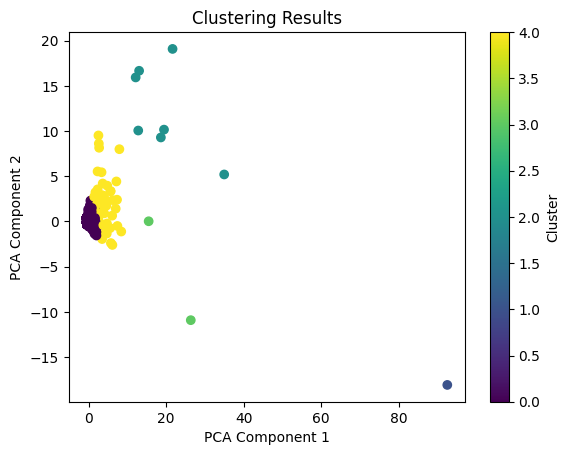

In [42]:
import matplotlib.pyplot as plt
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clustering Results')
plt.colorbar(label='Cluster')
plt.show()